In [ ]:
from datasets import load_dataset

/Users/scottstossel/side-projects/rag-eval/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating validation split: 100%|██████████| 10570/10570 [00:00<00:00, 2019026.93 examples/s]


In [9]:
dataset = load_dataset("squad", split="train[:1000]")

In [12]:
print("Dataset length: ", len(dataset))
unique_contexts = list(set(dataset["context"]))
print("Unique contexts: ", len(unique_contexts))
print("Unique questions: ", len(set(dataset["question"])))

Dataset length:  1000
Unique contexts:  119
Unique questions:  998


In [13]:
import numpy as np
context_lengths = [len(context.split()) for context in dataset["context"]]
print("Mean context length: ", np.mean(context_lengths))
print("Max context length: ", np.max(context_lengths))
print("Min context length: ", np.min(context_lengths))

Mean context length:  142.815
Max context length:  326
Min context length:  26


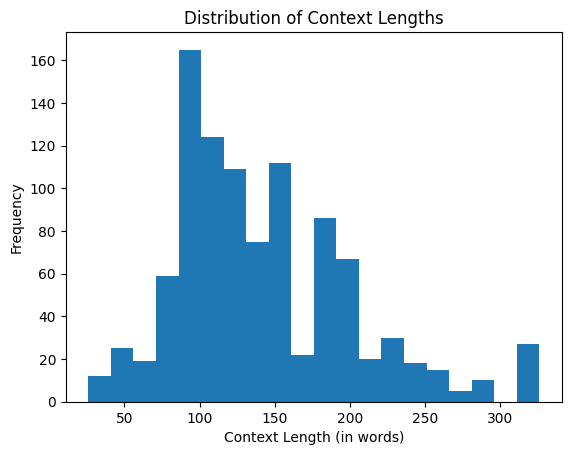

In [15]:
import matplotlib.pyplot as plt
plt.hist(context_lengths, bins=20)
plt.title("Distribution of Context Lengths")
plt.xlabel("Context Length (in words)")
plt.ylabel("Frequency")
plt.show()

In [16]:
question_lengths = [len(question.split()) for question in dataset["question"]]
print("Mean question length: ", np.mean(question_lengths))

Mean question length:  10.361


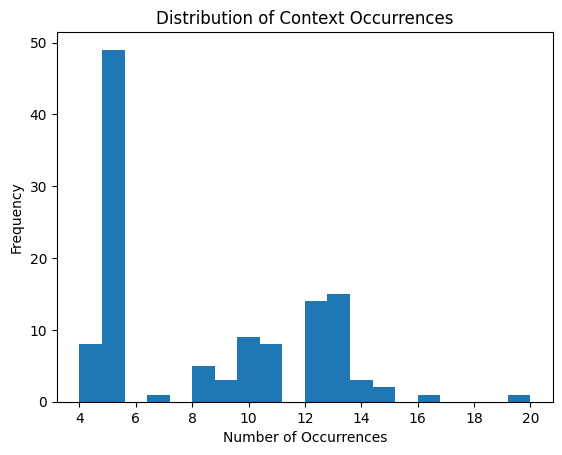

Min Q per context: 4
Max Q per context: 20
Mean Q per context: 8.403361344537815


In [19]:
from collections import Counter
context_word_counts = Counter(dataset["context"])
counts = list(context_word_counts.values())
plt.hist(counts, bins=20)
plt.title("Distribution of Context Occurrences")
plt.xlabel("Number of Occurrences")
plt.ylabel("Frequency")
plt.show()


print("Min Q per context:", min(counts))
print("Max Q per context:", max(counts))
print("Mean Q per context:", np.mean(counts))

In [18]:
def check_answer_in_context(row):
    answer = row["answers"]["text"][0]
    return answer in row["context"]

precense = [check_answer_in_context(r) for r in dataset]
print("Answer present rate: ", sum(precense)/len(precense))

Answer present rate:  1.0


In [24]:
dataset[:9]

{'id': ['5733be284776f41900661182',
  '5733be284776f4190066117f',
  '5733be284776f41900661180',
  '5733be284776f41900661181',
  '5733be284776f4190066117e',
  '5733bf84d058e614000b61be',
  '5733bf84d058e614000b61bf',
  '5733bf84d058e614000b61c0',
  '5733bf84d058e614000b61bd'],
 'title': ['University_of_Notre_Dame',
  'University_of_Notre_Dame',
  'University_of_Notre_Dame',
  'University_of_Notre_Dame',
  'University_of_Notre_Dame',
  'University_of_Notre_Dame',
  'University_of_Notre_Dame',
  'University_of_Notre_Dame',
  'University_of_Notre_Dame'],
 'context': ['Architecturally, the school has a Catholic character. Atop the Main Building\'s gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend "Venite Ad Me Omnes". Next to the Main Building is the Basilica of the Sacred Heart. Immediately behind the basilica is the Grotto, a Marian place of prayer and reflection. It is 

In [25]:
documents = []
context_to_doc_id = {}

for i, context in enumerate(unique_contexts):
    doc_id = f"doc_{i}"
    documents.append({
        "doc_id": doc_id,
        "text": context
    })
    context_to_doc_id[context] = doc_id

In [26]:
qa_pairs = []

for row in dataset:
    qa_pairs.append({
        "question": row["question"],
        "answer": row["answers"]["text"][0],
        "gold_doc_id": context_to_doc_id[row["context"]]
    })